# Multi-Judge Pairwise Win Rates and Agreement

This notebook aggregates `answer_winrate-original` results across LLM judges. It currently combines `old-llama-70b` and `gpt-5.4-mini`; `qwen3.6-35b-a3b` is already listed and will be included automatically after its output file is created. The tables report the mean and sample standard deviation across judges, while the publication graph intentionally plots only the mean.

In [1]:
from itertools import combinations
from pathlib import Path

from IPython.display import display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 160)


def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd() if start is None else start
    for candidate in (start, *start.parents):
        if (candidate / "evaluations").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find repository root containing evaluations/ and pyproject.toml")


REPO_ROOT = find_repo_root()
EVALUATIONS_DIR = REPO_ROOT / "evaluations"
ANSWER_REPORT = "original"
WINRATE_DIRNAME = f"answer_winrate-{ANSWER_REPORT}"

# Missing output files are skipped. Qwen will join the ensemble automatically when its run is complete.
JUDGE_IDS = [
    "old-llama-70b",
    "gpt-5.4-mini",
    "qwen3.6-35b-a3b",
]
JUDGE_LABELS = {
    "old-llama-70b": "Llama 3.3 70B",
    "gpt-5.4-mini": "GPT-5.4 mini",
    "qwen3.6-35b-a3b": "Qwen 3.6 35B",
}
DATASETS = [
    ("chatbs-base", "ChatBS"),
    ("biomni-base", "Biomni"),
]
MIN_JUDGES_PER_DATASET = 2

METHOD_ORDER = [
    "llmbased",
    "vectorsimilarity",
    "grasp",
    "hipporag",
    "hypergraphrag",
]
METHOD_LABELS = {
    "llmbased": "GWB",
    "vectorsimilarity": "VSB",
    "hipporag": "HippoRAG",
    "hypergraphrag": "HyperGRAG",
    "grasp": "GRASP",
    "ours": "Ours",
    "LWE": "Ours",
}
OUTCOME_ORDER = ["ours_win", "opponent_win", "tie"]

FIGURE_DIR = REPO_ROOT / "paper_figures" / "judges" / "ensemble"
TABLE_DIR = REPO_ROOT / "paper_tables" / "judges" / "ensemble"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

REPO_ROOT

PosixPath('/home/desild/work/research/LLM-Workflow-Explorer')

## Aggregation Method

For each judge and Ours-versus-baseline pairing, the win rate is `(Ours wins + 0.5 * ties) / comparisons`. The ensemble value is the arithmetic mean of those judge-level win rates, so every judge receives equal weight. The reported standard deviation is the sample standard deviation across judges (`ddof=1`). It measures sensitivity to judge choice, not sampling uncertainty over questions; with only two judges it should be treated as descriptive. The graph below uses only the ensemble mean and does not draw error bars.

In [2]:
def read_csv_or_empty(path: Path) -> pd.DataFrame:
    if not path.exists() or path.stat().st_size == 0:
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        return pd.DataFrame()


def pairwise_output_path(dataset_id: str, judge_id: str) -> Path:
    return (
        EVALUATIONS_DIR
        / dataset_id
        / "analysis"
        / "judges"
        / judge_id
        / WINRATE_DIRNAME
        / "pairwise_answer_winrate.csv"
    )


def canonicalize_pairwise_methods(pairwise_df: pd.DataFrame) -> pd.DataFrame:
    if pairwise_df.empty:
        return pairwise_df

    required = {"ground_truth_id", "method_a", "method_b", "winning_method"}
    missing = required.difference(pairwise_df.columns)
    if missing:
        raise ValueError(f"Pairwise file is missing required columns: {sorted(missing)}")

    df = pairwise_df.copy()
    original_a = df["method_a"].astype(str)
    original_b = df["method_b"].astype(str)

    if "method_a_key" in df.columns:
        df["method_a"] = df["method_a_key"].fillna(df["method_a"])
    if "method_b_key" in df.columns:
        df["method_b"] = df["method_b_key"].fillna(df["method_b"])

    df["method_a"] = df["method_a"].replace({"LWE": "ours"})
    df["method_b"] = df["method_b"].replace({"LWE": "ours"})

    winning = df["winning_method"].copy()
    winning = winning.mask(winning.astype(str).eq(original_a), df["method_a"])
    winning = winning.mask(winning.astype(str).eq(original_b), df["method_b"])
    df["winning_method"] = winning.replace({"LWE": "ours"})
    return df


def select_ours_comparisons(pairwise_df: pd.DataFrame) -> pd.DataFrame:
    ours_rows = pairwise_df[
        pairwise_df["method_a"].eq("ours") | pairwise_df["method_b"].eq("ours")
    ].copy()
    ours_rows["opponent"] = np.where(
        ours_rows["method_a"].eq("ours"),
        ours_rows["method_b"],
        ours_rows["method_a"],
    )
    return ours_rows[ours_rows["opponent"].isin(METHOD_ORDER)].copy()


def pairwise_ours_summary(pairwise_df: pd.DataFrame) -> pd.DataFrame:
    ours_rows = select_ours_comparisons(pairwise_df)
    rows = []
    for opponent in METHOD_ORDER:
        subset = ours_rows[ours_rows["opponent"].eq(opponent)]
        if subset.empty:
            continue

        total = len(subset)
        ours_wins = int(subset["winning_method"].eq("ours").sum())
        opponent_wins = int(subset["winning_method"].eq(opponent).sum())
        ties = total - ours_wins - opponent_wins
        rows.append({
            "opponent": opponent,
            "comparisons": total,
            "ours_wins": ours_wins,
            "opponent_wins": opponent_wins,
            "ties": ties,
            "ours_winrate": (ours_wins + 0.5 * ties) / total,
        })
    return pd.DataFrame(rows)


def item_level_decisions(pairwise_df: pd.DataFrame) -> pd.DataFrame:
    decisions = select_ours_comparisons(pairwise_df)
    decisions["outcome"] = np.select(
        [
            decisions["winning_method"].eq("ours"),
            decisions["winning_method"].eq(decisions["opponent"]),
        ],
        ["ours_win", "opponent_win"],
        default="tie",
    )
    decisions["item_id"] = (
        decisions["ground_truth_id"].astype(str)
        + "::"
        + decisions["opponent"].astype(str)
    )
    if decisions["item_id"].duplicated().any():
        duplicates = decisions.loc[decisions["item_id"].duplicated(), "item_id"].tolist()
        raise ValueError(f"Duplicate judge decisions found for items: {duplicates[:5]}")
    return decisions[["ground_truth_id", "opponent", "item_id", "outcome"]]


In [3]:
judge_summary_frames = []
decision_frames = []
availability_rows = []

for dataset_id, dataset_label in DATASETS:
    for judge_id in JUDGE_IDS:
        pairwise_path = pairwise_output_path(dataset_id, judge_id)
        pairwise_df = canonicalize_pairwise_methods(read_csv_or_empty(pairwise_path))
        available = not pairwise_df.empty
        availability_rows.append({
            "dataset": dataset_label,
            "judge_id": judge_id,
            "judge": JUDGE_LABELS.get(judge_id, judge_id),
            "available": available,
            "path": str(pairwise_path.relative_to(REPO_ROOT)),
        })
        if not available:
            continue

        judge_summary = pairwise_ours_summary(pairwise_df)
        judge_summary.insert(0, "dataset_id", dataset_id)
        judge_summary.insert(1, "dataset", dataset_label)
        judge_summary.insert(2, "judge_id", judge_id)
        judge_summary.insert(3, "judge", JUDGE_LABELS.get(judge_id, judge_id))
        judge_summary["opponent_label"] = judge_summary["opponent"].map(METHOD_LABELS)
        judge_summary["ours_winrate_pct"] = judge_summary["ours_winrate"] * 100
        judge_summary_frames.append(judge_summary)

        decisions = item_level_decisions(pairwise_df)
        decisions.insert(0, "dataset_id", dataset_id)
        decisions.insert(1, "dataset", dataset_label)
        decisions.insert(2, "judge_id", judge_id)
        decision_frames.append(decisions)

availability = pd.DataFrame(availability_rows)
judge_winrates = pd.concat(judge_summary_frames, ignore_index=True)
all_decisions = pd.concat(decision_frames, ignore_index=True)

judge_counts = judge_winrates.groupby("dataset_id")["judge_id"].nunique()
eligible_dataset_ids = judge_counts[judge_counts.ge(MIN_JUDGES_PER_DATASET)].index
skipped_dataset_ids = judge_counts[judge_counts.lt(MIN_JUDGES_PER_DATASET)].index.tolist()
if skipped_dataset_ids:
    print(
        "Skipping datasets with fewer than "
        f"{MIN_JUDGES_PER_DATASET} completed judges: {skipped_dataset_ids}"
    )

judge_winrates = judge_winrates[judge_winrates["dataset_id"].isin(eligible_dataset_ids)].copy()
decisions = all_decisions[all_decisions["dataset_id"].isin(eligible_dataset_ids)].copy()
if judge_winrates.empty:
    raise ValueError("No dataset has enough completed judge outputs to build an ensemble.")

aggregate_winrates = (
    judge_winrates
    .groupby(["dataset_id", "dataset", "opponent", "opponent_label"], as_index=False)
    .agg(
        judge_count=("judge_id", "nunique"),
        comparisons_per_judge_min=("comparisons", "min"),
        comparisons_per_judge_max=("comparisons", "max"),
        ours_winrate_mean=("ours_winrate", "mean"),
        ours_winrate_std=("ours_winrate", "std"),
    )
)
aggregate_winrates["ours_winrate_mean_pct"] = aggregate_winrates["ours_winrate_mean"] * 100
aggregate_winrates["ours_winrate_std_pct"] = aggregate_winrates["ours_winrate_std"] * 100

judge_csv = TABLE_DIR / "original_answer_winrates_by_judge.csv"
aggregate_csv = TABLE_DIR / "original_answer_winrates_ensemble.csv"
judge_winrates.to_csv(judge_csv, index=False)
aggregate_winrates.to_csv(aggregate_csv, index=False)

print(f"Wrote {judge_csv.relative_to(REPO_ROOT)}")
print(f"Wrote {aggregate_csv.relative_to(REPO_ROOT)}")
display(availability[["dataset", "judge", "available", "path"]])
display(
    judge_winrates[["dataset", "judge", "opponent_label", "comparisons", "ours_winrate_pct"]]
    .sort_values(["dataset", "opponent_label", "judge"])
    .reset_index(drop=True)
)
display(
    aggregate_winrates[[
        "dataset",
        "opponent_label",
        "judge_count",
        "comparisons_per_judge_min",
        "comparisons_per_judge_max",
        "ours_winrate_mean_pct",
        "ours_winrate_std_pct",
    ]]
    .sort_values(["dataset", "opponent_label"])
    .reset_index(drop=True)
)

Wrote paper_tables/judges/ensemble/original_answer_winrates_by_judge.csv
Wrote paper_tables/judges/ensemble/original_answer_winrates_ensemble.csv


,dataset,judge,available,path
0,ChatBS,Llama 3.3 70B,True,evaluations/chatbs-base/analysis/judges/old-llama-70b/answer_winrate-original/pairwise_answer_winrate.csv
1,ChatBS,GPT-5.4 mini,True,evaluations/chatbs-base/analysis/judges/gpt-5.4-mini/answer_winrate-original/pairwise_answer_winrate.csv
2,ChatBS,Qwen 3.6 35B,True,evaluations/chatbs-base/analysis/judges/qwen3.6-35b-a3b/answer_winrate-original/pairwise_answer_winrate.csv
3,Biomni,Llama 3.3 70B,True,evaluations/biomni-base/analysis/judges/old-llama-70b/answer_winrate-original/pairwise_answer_winrate.csv
4,Biomni,GPT-5.4 mini,True,evaluations/biomni-base/analysis/judges/gpt-5.4-mini/answer_winrate-original/pairwise_answer_winrate.csv
5,Biomni,Qwen 3.6 35B,False,evaluations/biomni-base/analysis/judges/qwen3.6-35b-a3b/answer_winrate-original/pairwise_answer_winrate.csv


,dataset,judge,opponent_label,comparisons,ours_winrate_pct
0,Biomni,GPT-5.4 mini,GRASP,106,81.603774
1,Biomni,Llama 3.3 70B,GRASP,106,97.169811
2,Biomni,GPT-5.4 mini,GWB,106,84.905660
3,Biomni,Llama 3.3 70B,GWB,106,98.113208
4,Biomni,GPT-5.4 mini,HippoRAG,106,82.547170
5,Biomni,Llama 3.3 70B,HippoRAG,106,90.566038
6,Biomni,GPT-5.4 mini,HyperGRAG,106,72.641509
7,Biomni,Llama 3.3 70B,HyperGRAG,106,53.773585
8,Biomni,GPT-5.4 mini,VSB,106,74.528302
9,Biomni,Llama 3.3 70B,VSB,106,95.283019


,dataset,opponent_label,judge_count,comparisons_per_judge_min,comparisons_per_judge_max,ours_winrate_mean_pct,ours_winrate_std_pct
0,Biomni,GRASP,2,106,106,89.386792,11.006851
1,Biomni,GWB,2,106,106,91.509434,9.339146
2,Biomni,HippoRAG,2,106,106,86.556604,5.670196
3,Biomni,HyperGRAG,2,106,106,63.207547,13.341637
4,Biomni,VSB,2,106,106,84.905660,14.675801
5,ChatBS,GRASP,3,103,103,86.084142,4.350916
6,ChatBS,GWB,3,103,103,90.291262,5.405596
7,ChatBS,HippoRAG,3,103,103,88.834951,6.847930
8,ChatBS,HyperGRAG,3,103,103,65.210356,7.525577
9,ChatBS,VSB,3,103,103,83.333333,4.664575


## Mean and Standard-Deviation Table

The display and LaTeX table use `mean +/- sample SD` across the completed judges. The numeric CSV retains separate mean and standard-deviation columns for later analysis.

In [4]:
formatted_winrates = aggregate_winrates.copy()
formatted_winrates["mean_and_std"] = formatted_winrates.apply(
    lambda row: (
        f"{row['ours_winrate_mean_pct']:.1f} $\\pm$ "
        f"{row['ours_winrate_std_pct']:.1f}"
    ),
    axis=1,
)

table_df = formatted_winrates.pivot_table(
    index="opponent_label",
    columns="dataset",
    values="mean_and_std",
    aggfunc="first",
)
label_order = [METHOD_LABELS[method] for method in METHOD_ORDER]
dataset_order = [
    label for dataset_id, label in DATASETS
    if dataset_id in set(eligible_dataset_ids)
]
table_df = table_df.reindex(index=label_order, columns=dataset_order)
table_df = table_df.rename_axis("Baseline").reset_index()

table_csv = TABLE_DIR / "original_answer_winrates_ensemble_formatted.csv"
table_tex = TABLE_DIR / "original_answer_winrates_ensemble.tex"
table_df.to_csv(table_csv, index=False)
latex_table = table_df.to_latex(
    index=False,
    escape=False,
    column_format="l" + "c" * len(dataset_order),
    caption=(
        "Mean pairwise original-answer win rate (percent) of Ours against each baseline "
        "across LLM judges, with sample standard deviation. Ties count as half wins."
    ),
    label="tab:original-answer-ensemble-winrates",
)
table_tex.write_text(latex_table, encoding="utf-8")

print(f"Wrote {table_csv.relative_to(REPO_ROOT)}")
print(f"Wrote {table_tex.relative_to(REPO_ROOT)}")
table_df

Wrote paper_tables/judges/ensemble/original_answer_winrates_ensemble_formatted.csv
Wrote paper_tables/judges/ensemble/original_answer_winrates_ensemble.tex


dataset,Baseline,ChatBS,Biomni
0,GWB,90.3 $\pm$ 5.4,91.5 $\pm$ 9.3
1,VSB,83.3 $\pm$ 4.7,84.9 $\pm$ 14.7
2,GRASP,86.1 $\pm$ 4.4,89.4 $\pm$ 11.0
3,HippoRAG,88.8 $\pm$ 6.8,86.6 $\pm$ 5.7
4,HyperGRAG,65.2 $\pm$ 7.5,63.2 $\pm$ 13.3


## Mean-Only Paper Figure

Each bar is the mean win rate across available judges for that dataset and baseline. The sample standard deviation remains available in the tables but is intentionally not encoded in the graph.

Wrote paper_figures/judges/ensemble/original_answer_winrates_judge_ensemble.pdf
Wrote paper_figures/judges/ensemble/original_answer_winrates_judge_ensemble.png


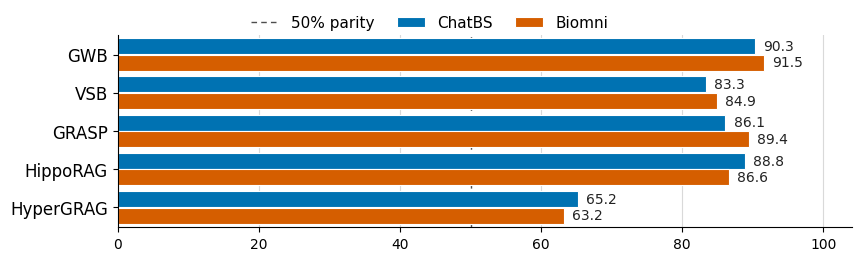

In [5]:
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.bbox": "tight",
})

DATASET_COLORS = {
    "ChatBS": "#0072B2",
    "Biomni": "#D55E00",
}
X_TICK_FONT_SIZE = 10
Y_TICK_FONT_SIZE = 12
AXIS_LABEL_FONT_SIZE = 11
LEGEND_FONT_SIZE = 11
BAR_VALUE_FONT_SIZE = 10

plot_df = aggregate_winrates.copy()
baseline_order = [
    method for method in METHOD_ORDER
    if method in set(plot_df["opponent"])
]
dataset_order = [
    label for dataset_id, label in DATASETS
    if dataset_id in set(plot_df["dataset_id"])
]

fig, ax = plt.subplots(figsize=(8.5, 2.5), constrained_layout=True)
row_spacing = 0.90
y_positions = np.arange(len(baseline_order)) * row_spacing
bar_height = min(0.50, 0.75 / max(len(dataset_order), 1))
bar_gap = 0.015

for index, dataset_label in enumerate(dataset_order):
    offset = (index - (len(dataset_order) - 1) / 2) * (bar_height + bar_gap)
    dataset_df = plot_df[plot_df["dataset"].eq(dataset_label)].set_index("opponent")
    values = [
        dataset_df.loc[method, "ours_winrate_mean_pct"]
        if method in dataset_df.index else np.nan
        for method in baseline_order
    ]

    # Deliberately no xerr: the requested graph encodes the ensemble mean only.
    bars = ax.barh(
        y_positions + offset,
        values,
        height=bar_height,
        color=DATASET_COLORS[dataset_label],
        edgecolor="white",
        linewidth=0.8,
        label=dataset_label,
    )
    for bar, value in zip(bars, values):
        if np.isnan(value):
            continue
        inside = value >= 93
        ax.text(
            value - 1.8 if inside else value + 1.2,
            bar.get_y() + bar.get_height() / 2,
            f"{value:.1f}",
            va="center",
            ha="right" if inside else "left",
            color="white" if inside else "#222222",
            fontsize=BAR_VALUE_FONT_SIZE,
            fontweight="bold" if inside else "normal",
        )

ax.axvline(
    50,
    color="#4d4d4d",
    linestyle=(0, (4, 3)),
    linewidth=1.0,
    zorder=0,
    label="50% parity",
)
ax.set_yticks(y_positions)
ax.set_yticklabels([METHOD_LABELS.get(method, method) for method in baseline_order])
ax.tick_params(axis="x", labelsize=X_TICK_FONT_SIZE)
ax.tick_params(axis="y", labelsize=Y_TICK_FONT_SIZE)
ax.invert_yaxis()
ax.set_xlim(0, 104)
ax.set_xticks(np.arange(0, 101, 20))
ax.set_xlabel("")
ax.set_ylabel("")
ax.xaxis.grid(True, color="#d9d9d9", linewidth=0.8)
ax.set_axisbelow(True)
ax.margins(y=0.02)
ax.legend(
    frameon=False,
    loc="lower center",
    bbox_to_anchor=(0.425, 0.95),
    ncols=len(dataset_order) + 1,
    columnspacing=1.5,
    handlelength=1.8,
    fontsize=LEGEND_FONT_SIZE,
)

figure_pdf = FIGURE_DIR / "original_answer_winrates_judge_ensemble.pdf"
figure_png = FIGURE_DIR / "original_answer_winrates_judge_ensemble.png"
fig.savefig(figure_pdf)
fig.savefig(figure_png, dpi=600)

print(f"Wrote {figure_pdf.relative_to(REPO_ROOT)}")
print(f"Wrote {figure_png.relative_to(REPO_ROOT)}")
plt.show()

## Item-Level LLM Agreement

Similar aggregate win rates do not imply agreement: two judges can produce the same overall percentage while choosing different winners on individual questions. Agreement is therefore calculated after aligning each decision by dataset, ground-truth question ID, and baseline opponent. Outcomes are normalized to `ours_win`, `opponent_win`, or `tie`, which remains valid even if method A and method B were presented in a different order.

- **Nominal Krippendorff's alpha** is the primary inter-rater statistic. It is computed directly from the item-level decisions, supports two or more judges, and can retain items with missing ratings as long as at least two ratings are available. A value of 1 is perfect agreement, 0 is agreement at the chance baseline implied by the pooled outcome frequencies, and negative values indicate systematic disagreement.
- **Raw agreement** is the percentage of matched pairwise decisions with exactly the same outcome. It is easy to interpret but does not correct for agreement expected from the outcome distribution.
- **Cohen's kappa** and confusion matrices are retained as pairwise diagnostics. They show which particular judge pairs and outcomes drive the overall alpha.

Alpha and kappa can be much lower than raw agreement when one outcome, such as `ours_win`, is very common. Krippendorff's alpha cannot be algebraically transformed from Cohen's or Fleiss' kappa; it is recomputed from the original decisions using nominal disagreement.

In [6]:
def cohen_kappa(labels_a: pd.Series, labels_b: pd.Series) -> tuple[float, float]:
    if len(labels_a) != len(labels_b) or labels_a.empty:
        return np.nan, np.nan
    observed = float(labels_a.eq(labels_b).mean())
    categories = sorted(set(labels_a.dropna()) | set(labels_b.dropna()))
    expected = sum(
        float(labels_a.eq(category).mean()) * float(labels_b.eq(category).mean())
        for category in categories
    )
    kappa = (observed - expected) / (1 - expected) if expected < 1 else np.nan
    return observed, kappa


def krippendorff_alpha_nominal(labels: pd.DataFrame) -> dict[str, float | int]:
    ratings_per_item = labels.notna().sum(axis=1)
    usable = labels.loc[ratings_per_item.ge(2)]
    if usable.empty:
        return {
            "items_used": 0,
            "ratings_used": 0,
            "min_ratings_per_item": 0,
            "max_ratings_per_item": 0,
            "unanimous_items_pct": np.nan,
            "observed_disagreement": np.nan,
            "expected_disagreement": np.nan,
            "krippendorff_alpha": np.nan,
        }

    observed_disagreement_numerator = 0.0
    category_totals = pd.Series(0, index=OUTCOME_ORDER, dtype=float)
    unanimous_items = 0
    for _, item_ratings in usable.iterrows():
        values = item_ratings.dropna()
        counts = values.value_counts().reindex(OUTCOME_ORDER, fill_value=0).astype(float)
        rating_count = len(values)
        observed_disagreement_numerator += (
            rating_count ** 2 - float((counts ** 2).sum())
        ) / (rating_count - 1)
        category_totals = category_totals.add(counts, fill_value=0)
        unanimous_items += int(values.nunique() == 1)

    usable_rating_counts = usable.notna().sum(axis=1)
    total_ratings = int(usable_rating_counts.sum())
    observed_disagreement = observed_disagreement_numerator / total_ratings
    expected_disagreement = (
        total_ratings ** 2 - float((category_totals ** 2).sum())
    ) / (total_ratings * (total_ratings - 1))
    alpha = (
        1 - observed_disagreement / expected_disagreement
        if expected_disagreement > 0 else np.nan
    )
    return {
        "items_used": len(usable),
        "ratings_used": total_ratings,
        "min_ratings_per_item": int(usable_rating_counts.min()),
        "max_ratings_per_item": int(usable_rating_counts.max()),
        "unanimous_items_pct": unanimous_items / len(usable) * 100,
        "observed_disagreement": observed_disagreement,
        "expected_disagreement": expected_disagreement,
        "krippendorff_alpha": alpha,
    }


decision_matrix = decisions.pivot_table(
    index=["dataset_id", "dataset", "ground_truth_id", "opponent"],
    columns="judge_id",
    values="outcome",
    aggfunc="first",
)
decision_matrix

judge_id                                              gpt-5.4-mini  \
dataset_id  dataset ground_truth_id opponent                         
biomni-base Biomni  gt_0            grasp                 ours_win   
                                    hipporag              ours_win   
                                    hypergraphrag     opponent_win   
                                    llmbased              ours_win   
                                    vectorsimilarity      ours_win   
...                                                            ...   
chatbs-base ChatBS  gt_99           grasp                 ours_win   
                                    hipporag              ours_win   
                                    hypergraphrag         ours_win   
                                    llmbased              ours_win   
                                    vectorsimilarity      ours_win   

judge_id                                             old-llama-70b  \
dataset_id  dataset ground_truth_id opponent                         
biomni-base Biomni  gt_0            grasp                 ours_win   
                                    hipporag              ours_win   
                                    hypergraphrag     opponent_win   
                                    llmbased              ours_win   
                                    vectorsimilarity      ours_win   
...                                                            ...   
chatbs-base ChatBS  gt_99           grasp                 ours_win   
                                    hipporag              ours_win   
                                    hypergraphrag         ours_win   
                                    llmbased              ours_win   
                                    vectorsimilarity      ours_win   

judge_id                                             qwen3.6-35b-a3b  
dataset_id  dataset ground_truth_id opponent                          
biomni-base Biomni  gt_0            grasp                        NaN  
                                    hipporag                     NaN  
                                    hypergraphrag                NaN  
                                    llmbased                     NaN  
                                    vectorsimilarity             NaN  
...                                                              ...  
chatbs-base ChatBS  gt_99           grasp                   ours_win  
                                    hipporag                ours_win  
                                    hypergraphrag           ours_win  
                                    llmbased                ours_win  
                                    vectorsimilarity        ours_win  

[1045 rows x 3 columns]

In [7]:
pairwise_agreement_rows = []
confusion_matrices = {}

for dataset_id, dataset_label in DATASETS:
    if dataset_id not in decision_matrix.index.get_level_values("dataset_id"):
        continue
    dataset_matrix = decision_matrix.xs(
        (dataset_id, dataset_label),
        level=("dataset_id", "dataset"),
    )
    active_judges = [judge for judge in JUDGE_IDS if judge in dataset_matrix.columns]
    scopes = [("all", "All plotted baselines", dataset_matrix)]
    scopes.extend(
        (
            opponent,
            METHOD_LABELS[opponent],
            dataset_matrix[dataset_matrix.index.get_level_values("opponent") == opponent],
        )
        for opponent in METHOD_ORDER
    )

    for judge_a, judge_b in combinations(active_judges, 2):
        for scope, scope_label, scoped_matrix in scopes:
            common = scoped_matrix[[judge_a, judge_b]].dropna()
            if common.empty:
                continue
            raw_agreement, kappa = cohen_kappa(common[judge_a], common[judge_b])
            pairwise_agreement_rows.append({
                "dataset_id": dataset_id,
                "dataset": dataset_label,
                "scope": scope,
                "scope_label": scope_label,
                "judge_a": judge_a,
                "judge_a_label": JUDGE_LABELS.get(judge_a, judge_a),
                "judge_b": judge_b,
                "judge_b_label": JUDGE_LABELS.get(judge_b, judge_b),
                "common_items": len(common),
                "raw_agreement": raw_agreement,
                "raw_agreement_pct": raw_agreement * 100,
                "cohen_kappa": kappa,
            })
            if scope == "all":
                confusion_matrices[(dataset_label, judge_a, judge_b)] = (
                    pd.crosstab(
                        common[judge_a],
                        common[judge_b],
                        rownames=[JUDGE_LABELS.get(judge_a, judge_a)],
                        colnames=[JUDGE_LABELS.get(judge_b, judge_b)],
                    )
                    .reindex(index=OUTCOME_ORDER, columns=OUTCOME_ORDER, fill_value=0)
                )

pairwise_agreement = pd.DataFrame(pairwise_agreement_rows)
pairwise_agreement_csv = TABLE_DIR / "pairwise_judge_agreement.csv"
pairwise_agreement.to_csv(pairwise_agreement_csv, index=False)
print(f"Wrote {pairwise_agreement_csv.relative_to(REPO_ROOT)}")
display(
    pairwise_agreement[[
        "dataset",
        "scope_label",
        "judge_a_label",
        "judge_b_label",
        "common_items",
        "raw_agreement_pct",
        "cohen_kappa",
    ]].round({"raw_agreement_pct": 1, "cohen_kappa": 3})
)

for (dataset_label, judge_a, judge_b), confusion in confusion_matrices.items():
    print(
        f"{dataset_label}: {JUDGE_LABELS.get(judge_a, judge_a)} vs "
        f"{JUDGE_LABELS.get(judge_b, judge_b)}"
    )
    display(confusion)

alpha_rows = []
for dataset_id, dataset_label in DATASETS:
    if dataset_id not in decision_matrix.index.get_level_values("dataset_id"):
        continue
    dataset_matrix = decision_matrix.xs(
        (dataset_id, dataset_label),
        level=("dataset_id", "dataset"),
    )
    active_judges = [judge for judge in JUDGE_IDS if judge in dataset_matrix.columns]
    if len(active_judges) < 2:
        continue
    scopes = [("all", "All plotted baselines", dataset_matrix)]
    scopes.extend(
        (
            opponent,
            METHOD_LABELS[opponent],
            dataset_matrix[dataset_matrix.index.get_level_values("opponent") == opponent],
        )
        for opponent in METHOD_ORDER
    )
    for scope, scope_label, scoped_matrix in scopes:
        alpha_stats = krippendorff_alpha_nominal(scoped_matrix[active_judges])
        if alpha_stats["items_used"] == 0:
            continue
        alpha_rows.append({
            "dataset_id": dataset_id,
            "dataset": dataset_label,
            "scope": scope,
            "scope_label": scope_label,
            "judge_count": len(active_judges),
            "judges": ", ".join(active_judges),
            **alpha_stats,
        })

krippendorff_agreement = pd.DataFrame(
    alpha_rows,
    columns=[
        "dataset_id",
        "dataset",
        "scope",
        "scope_label",
        "judge_count",
        "judges",
        "items_used",
        "ratings_used",
        "min_ratings_per_item",
        "max_ratings_per_item",
        "unanimous_items_pct",
        "observed_disagreement",
        "expected_disagreement",
        "krippendorff_alpha",
    ],
)
alpha_csv = TABLE_DIR / "krippendorff_alpha_agreement.csv"
krippendorff_agreement.to_csv(alpha_csv, index=False)
print(f"Wrote {alpha_csv.relative_to(REPO_ROOT)}")
display(
    krippendorff_agreement[[
        "dataset",
        "scope_label",
        "judge_count",
        "items_used",
        "ratings_used",
        "unanimous_items_pct",
        "observed_disagreement",
        "expected_disagreement",
        "krippendorff_alpha",
    ]].round({
        "unanimous_items_pct": 1,
        "observed_disagreement": 3,
        "expected_disagreement": 3,
        "krippendorff_alpha": 3,
    })
)

Wrote paper_tables/judges/ensemble/pairwise_judge_agreement.csv


,dataset,scope_label,judge_a_label,judge_b_label,common_items,raw_agreement_pct,cohen_kappa
0,ChatBS,All plotted baselines,Llama 3.3 70B,GPT-5.4 mini,515,80.4,0.349
1,ChatBS,GWB,Llama 3.3 70B,GPT-5.4 mini,103,85.4,0.324
2,ChatBS,VSB,Llama 3.3 70B,GPT-5.4 mini,103,81.6,0.366
3,ChatBS,GRASP,Llama 3.3 70B,GPT-5.4 mini,103,84.5,0.417
4,ChatBS,HippoRAG,Llama 3.3 70B,GPT-5.4 mini,103,81.6,0.179
5,ChatBS,HyperGRAG,Llama 3.3 70B,GPT-5.4 mini,103,68.9,0.341
6,ChatBS,All plotted baselines,Llama 3.3 70B,Qwen 3.6 35B,515,88.2,0.565
7,ChatBS,GWB,Llama 3.3 70B,Qwen 3.6 35B,103,90.3,0.238
8,ChatBS,VSB,Llama 3.3 70B,Qwen 3.6 35B,103,88.3,0.552
9,ChatBS,GRASP,Llama 3.3 70B,Qwen 3.6 35B,103,90.3,0.531


ChatBS: Llama 3.3 70B vs GPT-5.4 mini


GPT-5.4 mini,ours_win,opponent_win,tie
Llama 3.3 70B,,,
ours_win,374,58,5
opponent_win,31,40,5
tie,2,0,0


ChatBS: Llama 3.3 70B vs Qwen 3.6 35B


...

Qwen 3.6 35B,ours_win,opponent_win,tie
GPT-5.4 mini,,,
ours_win,373,32,2
opponent_win,50,47,1
tie,4,6,0


Biomni: Llama 3.3 70B vs GPT-5.4 mini


GPT-5.4 mini,ours_win,opponent_win,tie
Llama 3.3 70B,,,
ours_win,386,72,3
opponent_win,30,34,5
tie,0,0,0


Wrote paper_tables/judges/ensemble/krippendorff_alpha_agreement.csv


,dataset,scope_label,judge_count,items_used,ratings_used,unanimous_items_pct,observed_disagreement,expected_disagreement,krippendorff_alpha
0,ChatBS,All plotted baselines,3,515,1545,75.3,0.166,0.295,0.437
1,ChatBS,GWB,3,103,309,80.6,0.129,0.176,0.264
2,ChatBS,VSB,3,103,309,77.7,0.152,0.288,0.472
3,ChatBS,GRASP,3,103,309,79.6,0.139,0.247,0.436
4,ChatBS,HippoRAG,3,103,309,79.6,0.139,0.209,0.333
5,ChatBS,HyperGRAG,3,103,309,59.2,0.272,0.477,0.430
6,Biomni,All plotted baselines,3,530,1060,79.2,0.208,0.288,0.280
7,Biomni,GWB,3,106,212,84.9,0.151,0.156,0.033
8,Biomni,VSB,3,106,212,77.4,0.226,0.258,0.121
9,Biomni,GRASP,3,106,212,82.1,0.179,0.195,0.082


## How to Report These Results

Report the ensemble win rate as the judge-level mean with sample SD, for example `mean = 84.7%, SD = 5.1%`. Report nominal Krippendorff's alpha as the primary agreement statistic, together with the number of items and ratings used. Raw agreement, pairwise Cohen's kappa, and confusion matrices can be included as diagnostics. Avoid interpreting the SD as a confidence interval or alpha using rigid universal labels; outcome prevalence and the confusion matrix provide essential context.

To add Qwen, place its completed file at `evaluations/<dataset>/analysis/judges/qwen3.6-35b-a3b/answer_winrate-original/pairwise_answer_winrate.csv` and rerun the notebook. Alpha will then use all available ratings, including partially rated items with at least two judge decisions; no code change is required.